In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from torchvision import models
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# === CONFIGURATION ===
class Config:
    OUTPUT_DIR = 'working'
    BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_model.pt")

config = Config()

# === DATASET ===
class MelSpectrogramDataset(Dataset):
    def __init__(self, data_dict, label_dict):
        self.samples = list(data_dict.keys())
        self.data_dict = data_dict
        self.label_dict = label_dict

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        samplename = self.samples[idx]
        mel = self.data_dict[samplename]
        label = self.label_dict[samplename]
        mel_tensor = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label_tensor = torch.tensor(label, dtype=torch.long)
        return mel_tensor, label_tensor
    

# === Data loaders ===

def load_file(file):
    samplename = file.stem
    species_id = samplename.split("-")[0]
    mel_spec = np.load(file)
    return samplename, mel_spec, species_id

def load_data_structure_parallel(root_dir, max_workers=8):
    loaded_data = {}
    sample_to_label = {}

    files = [file for class_dir in Path(root_dir).iterdir() if class_dir.is_dir()
             for file in class_dir.glob("*.npy")]

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_file = {executor.submit(load_file, file): file for file in files}
        for future in as_completed(future_to_file):
            samplename, mel_spec, species_id = future.result()
            loaded_data[samplename] = mel_spec
            sample_to_label[samplename] = species_id

    return loaded_data, sample_to_label

def prepare_dataloaders(data_dict, label_dict, batch_size, train_names=None, val_names=None, label_encoder=None):
    sample_names = sorted(label_dict.keys())

    if label_encoder is None:
        label_encoder = LabelEncoder()
        label_encoder.fit(list(label_dict.values()))

    # Map sample_name -> encoded label correctly
    sample_to_encoded = {
        sample_name: label_encoder.transform([label_dict[sample_name]])[0]
        for sample_name in sample_names
    }

    # Use saved train/val names if provided
    if train_names is None or val_names is None:
        train_names, val_names = train_test_split(sample_names, test_size=0.2, random_state=42)

    train_data = {k: data_dict[k] for k in train_names}
    val_data = {k: data_dict[k] for k in val_names}
    train_labels = {k: sample_to_encoded[k] for k in train_names}
    val_labels = {k: sample_to_encoded[k] for k in val_names}

    train_ds = MelSpectrogramDataset(train_data, train_labels)
    val_ds = MelSpectrogramDataset(val_data, val_labels)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size)

    return train_dl, val_dl, len(label_encoder.classes_), label_encoder




# === MODEL ===
class MelCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )
        self.adaptive_pool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            return torch.argmax(logits, dim=1)

class MelResNetInference(nn.Module):
    def __init__(self, num_classes, backbone_name="resnet18"):
        super().__init__()
        
        # Choose backbone based on the name (no pretrained weights)
        if backbone_name == "resnet18":
            self.backbone = models.resnet18(weights=None)
        elif backbone_name == "resnet34":
            self.backbone = models.resnet34(weights=None)
        elif backbone_name == "resnet50":
            self.backbone = models.resnet50(weights=None)
        elif backbone_name == "resnet101":
            self.backbone = models.resnet101(weights=None)
        elif backbone_name == "resnet152":
            self.backbone = models.resnet152(weights=None)
        else:
            raise ValueError(f"Unknown backbone: {backbone_name}")
        
        # Adjust the first conv layer for 1-channel input
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        # Replace the final fully connected layer
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            return torch.argmax(logits, dim=1)

    @classmethod
    def load_from_checkpoint(cls, checkpoint_path, num_classes, backbone_name="resnet18"):
        model = cls(num_classes, backbone_name=backbone_name)
        model.load_state_dict(torch.load(checkpoint_path, map_location="cpu"))
        model.eval()
        return model

# === EVALUATION ===
def evaluate_roc_auc(model, dataloader, device, num_classes):
    model.eval()
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = F.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_targets.append(y.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    y_true = label_binarize(all_targets, classes=np.arange(num_classes))
    scored_classes = np.where(y_true.sum(axis=0) > 0)[0]

    if len(scored_classes) == 0:
        return 0.0

    try:
        return roc_auc_score(y_true[:, scored_classes], all_probs[:, scored_classes], average="macro")
    except ValueError:
        return 0.0
    
# Calculate accuracies
def evaluate_accuracy(model, val_dl, device='cuda'):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in val_dl:
            inputs, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    acc = accuracy_score(all_labels.numpy(), all_preds.numpy())
    return acc

def evaluate_f1(model, dataloader, device):
    """
    Returns (macro_f1, weighted_f1) scores.
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            preds = model.predict(x)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
    return macro_f1, weighted_f1


In [2]:
ROOT_DIR = Path(config.OUTPUT_DIR) / "mel_spectrograms"
loaded_bird_data, sample_to_label = load_data_structure_parallel(ROOT_DIR)

# Load saved splits
train_names = np.load(os.path.join(config.OUTPUT_DIR, "train_names.npy"), allow_pickle=True).tolist()
val_names = np.load(os.path.join(config.OUTPUT_DIR, "val_names.npy"), allow_pickle=True).tolist()

# Load label encoder
label_encoder = joblib.load(os.path.join(config.OUTPUT_DIR, "label_encoder.pkl"))
print("✅ Loaded LabelEncoder.")

# Pass them in
train_dl, val_dl, num_classes, label_encoder = prepare_dataloaders(
    loaded_bird_data, sample_to_label, batch_size=32, 
    train_names=train_names, val_names=val_names, label_encoder=label_encoder
)

✅ Loaded LabelEncoder.


In [ ]:
checkpoint_paths = {
    "resnet18": "working/best_model_res18_20_ep.pt",
    "resnet18_transfer_learning_head_only": "lucy_working/best_model_new_work_flow_resnet18_finetune_head_only.pt",
    "resnet18_transfer_learning_full_tune": "lucy_working/best_model_new_work_flow_resnet18_finetune_full.pt",
}

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load models properly
model_res18_load = MelResNetInference.load_from_checkpoint(
    checkpoint_path=checkpoint_paths["resnet18"],
    num_classes=num_classes,
    backbone_name="resnet18"
)

# Load models properly
model_res18_load2 = MelResNetInference.load_from_checkpoint(
    checkpoint_path=checkpoint_paths["resnet18_transfer_learning_head_only"],
    num_classes=num_classes,
    backbone_name="resnet18"
)

# Load models properly
model_res18_load3 = MelResNetInference.load_from_checkpoint(
    checkpoint_path=checkpoint_paths["resnet18_transfer_learning_full_tune"],
    num_classes=num_classes,
    backbone_name="resnet18"
)

# Move all models to device
model_res18_load = model_res18_load.to(device)
model_res18_load2 = model_res18_load2.to(device)
model_res18_load3 = model_res18_load3.to(device)

In [ ]:
# Group models
models = {
    "ResNet18 (Basic)": model_res18_load,
    "ResNet18 (Head-Only Transfer Learning)": model_res18_load2,
    "ResNet18 (Full-Network Transfer Learning)": model_res18_load3,
}

# Collect results into a list
results = []

print("Model Validation Metrics (ROC AUC, Accuracy, F1 Macro, F1 Weighted):")
for model_name, model in models.items():
    roc_auc = evaluate_roc_auc(model, val_dl, device, num_classes)
    acc = evaluate_accuracy(model, val_dl, device)
    macro_f1, weighted_f1 = evaluate_f1(model, val_dl, device)
    
    results.append({
        "Model": model_name,
        "ROC AUC": roc_auc,
        "Accuracy": acc,
        "F1 Macro": macro_f1,
        "F1 Weighted": weighted_f1
    })
    print(f"{model_name}: ROC AUC = {roc_auc:.4f} | Accuracy = {acc:.4f} | F1 Macro = {macro_f1:.4f} | F1 Weighted = {weighted_f1:.4f}")

# Create DataFrame
results_df = pd.DataFrame(results)


Model Validation Metrics (ROC AUC, Accuracy, F1 Macro, F1 Weighted):
ResNet18 (Basic): ROC AUC = 0.9802 | Accuracy = 0.7203 | F1 Macro = 0.5822 | F1 Weighted = 0.7126
ResNet18 (Head_only_transfer_learning): ROC AUC = 0.9771 | Accuracy = 0.7238 | F1 Macro = 0.5764 | F1 Weighted = 0.7192
ResNet18 (full_network_transfer_learning): ROC AUC = 0.9760 | Accuracy = 0.7271 | F1 Macro = 0.5803 | F1 Weighted = 0.7219


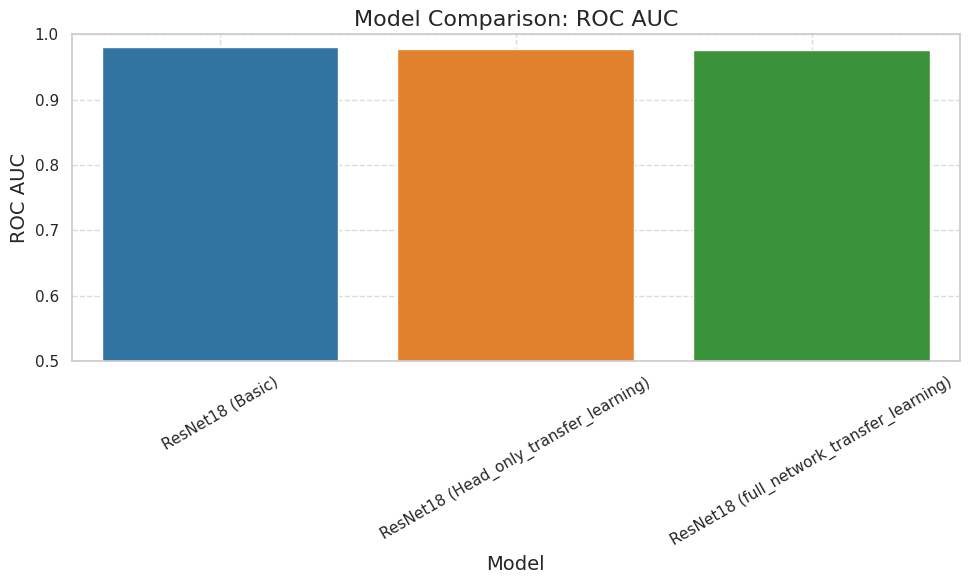

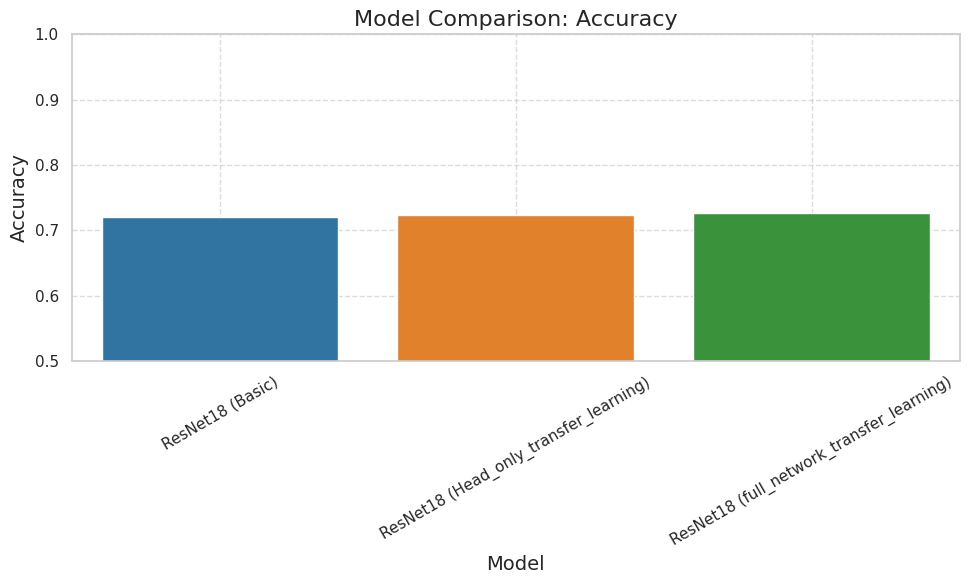

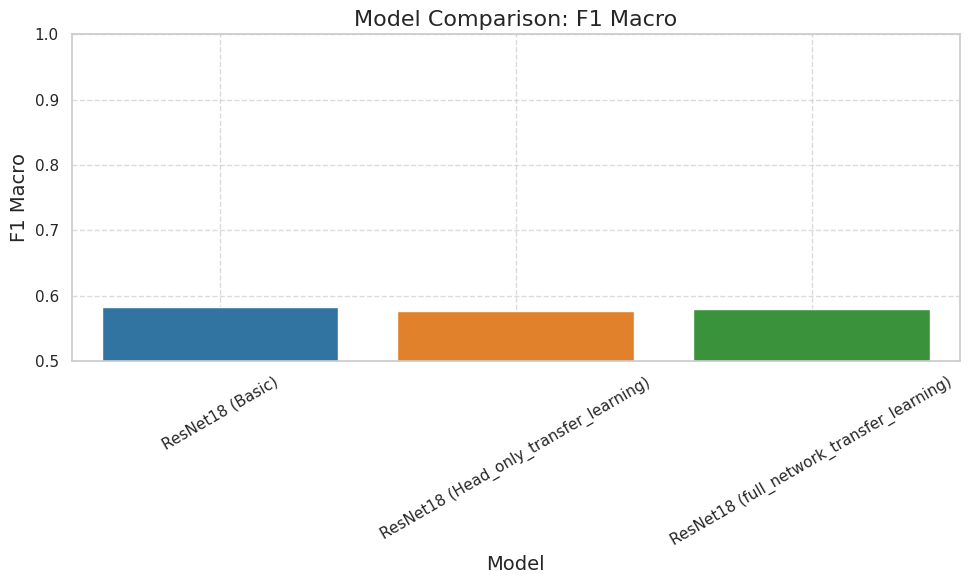

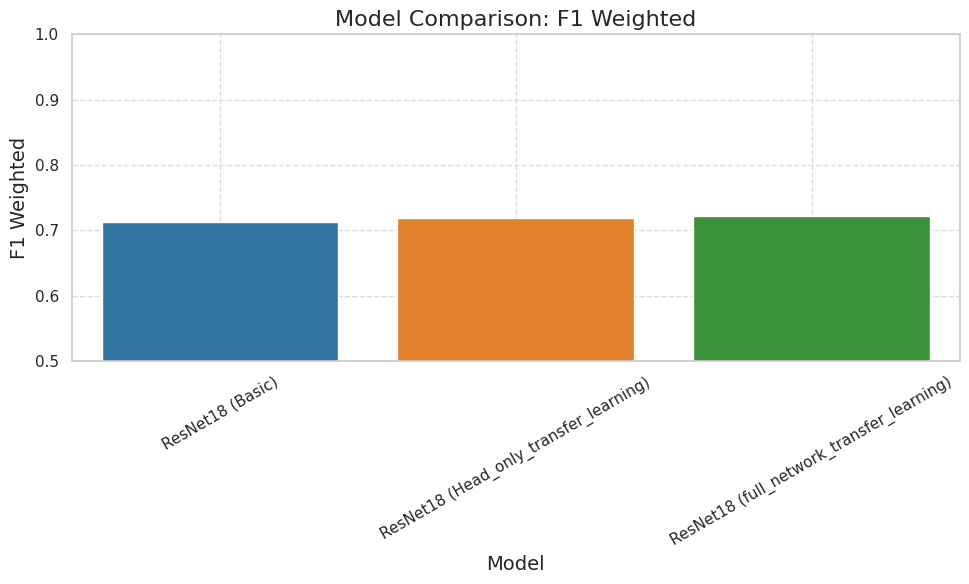

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

metrics = ["ROC AUC", "Accuracy", "F1 Macro", "F1 Weighted"]

for metric in metrics:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x="Model", 
        y=metric, 
        hue="Model", 
        data=results_df, 
        palette="tab10", 
        dodge=False, 
        legend=False
    )
    
    plt.title(f"Model Comparison: {metric}", fontsize=16)
    plt.ylabel(metric, fontsize=14)
    plt.xlabel("Model", fontsize=14)
    plt.xticks(rotation=30)
    plt.ylim((0.5, 1.0))
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()



In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# === Load taxonomy to map label codes to scientific names ===
taxonomy_df = pd.read_csv("/kaggle/input/birdclef-2025/taxonomy.csv")
label_to_sci = dict(zip(taxonomy_df['primary_label'], taxonomy_df['scientific_name']))

# === Convert predictions and labels to numpy arrays ===
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# === Identify top 10 most frequent true labels in validation set ===
val_counts = pd.Series(all_labels).value_counts()
top10_class_indices = val_counts.head(10).index.tolist()

# === Filter predictions and labels to include only top 10 classes (true label must be in top 10) ===
mask = np.isin(all_labels, top10_class_indices)
filtered_preds = all_preds[mask]
filtered_labels = all_labels[mask]

# === Filter out predictions not in top 10 to ensure square matrix ===
filtered_pairs = [
    (pred, label)
    for pred, label in zip(filtered_preds, filtered_labels)
    if pred in top10_class_indices
]

# === Remap class indices to range 0–9 ===
index_mapping = {old: new for new, old in enumerate(top10_class_indices)}
remapped_preds = [index_mapping[pred] for pred, _ in filtered_pairs]
remapped_labels = [index_mapping[label] for _, label in filtered_pairs]

# === Get scientific names for the top 10 classes ===
class_names = label_encoder.classes_
top10_class_codes = [class_names[i] for i in top10_class_indices]
top10_class_sci_names = [label_to_sci.get(code, code) for code in top10_class_codes]

# === Create and normalize the confusion matrix ===
cm = confusion_matrix(remapped_labels, remapped_preds, labels=range(10))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# === Plot normalized confusion matrix ===
df_cm = pd.DataFrame(cm_normalized, index=top10_class_sci_names, columns=top10_class_sci_names)

plt.figure(figsize=(10, 9))
sns.set(font_scale=1.0)
sns.heatmap(df_cm, annot=True, fmt='.2f', cmap='Blues', square=True, cbar=True, linewidths=0.5)

plt.title("Top 10 Species Confusion Matrix", fontsize=14)
plt.xlabel("Predicted label", fontsize=12)
plt.ylabel("True label", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
